# Desafio AutoCred — modelagem da PD e faixas de score

Este notebook é a **defesa visual** dos capítulos [04 — Modelo](../docs/04-modelo.md) e
[05 — Score](../docs/05-score.md). Ele não decide nada: as decisões estão nos capítulos, com a
alternativa descartada ao lado de cada uma. Aqui ficam as seis figuras que uma tabela não entrega.

O problema: a AutoCred financia veículos e precisa estimar, para cada proposta, a probabilidade de
o contrato atingir **90 dias de atraso nos 12 meses seguintes à concessão** — a PD. Essa
probabilidade vira uma **faixa de score de 1 a 10** (1 = pior risco), e é sobre a faixa que a
política de crédito decide aprovar, a que taxa, em que prazo e com quanta entrada.

Três regras atravessam tudo o que está abaixo:

> **A safra de 2024 é tocada uma vez.** Hiperparâmetro sai de validação cruzada dentro de
> 2022-2023. Buscar parâmetro olhando 2024 transforma o *out-of-time* em mais um conjunto de
> treino, e a estimativa vira propaganda.
>
> **Nenhuma coluna posterior à concessão entra como preditora.** A mais preditiva da base,
> `qtd_parcelas_em_atraso_12m`, é proibida por ser comportamento pós-concessão — e chega zerada
> nas bases B e C. Ver [01 — Dados](../docs/01-dados.md).
>
> **Calibração é medida, não presumida.** O AuROC não enxerga se a PD prevista vale 3% ou 30%, e é
> exatamente disso que a política precisa.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "src"))

from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve

from dados import ALVO, carregar_base_a, carregar_base_b, carregar_base_c
from exploracao import classificar_psi
from features import matriz, montar_pipeline, preparar_aplicacao
from modelo import candidatos, comparar, dividir, tabela_calibracao, treinar_final, prever
from score import CORTES, estabilidade, faixa, pares_indistinguiveis, pd_base_a, tabela_faixas

AZUL, LARANJA, VERDE = "#2a78d6", "#eb6834", "#1f9e6e"
NEUTRO, TINTA, SECUNDARIA, EIXO, GRADE = "#f0efec", "#0b0b0b", "#52514e", "#c3c2b7", "#e1e0d9"
RAMPA_AZUL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": EIXO, "axes.labelcolor": SECUNDARIA, "axes.titlecolor": TINTA,
    "axes.grid": True, "grid.color": GRADE, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": SECUNDARIA, "ytick.color": SECUNDARIA,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.dpi": 110, "savefig.bbox": "tight",
})
pd.set_option("display.width", 140)

# Português usa vírgula decimal. O eixo do matplotlib não sabe disso, e gráfico
# com "0.74" ao lado de um texto com "0,74" é o tipo de descuido que o leitor de
# portfólio nota antes do conteúdo.
VIRGULA = FuncFormatter(lambda v, _: f"{v:g}".replace(".", ","))
br = lambda v, casas=1, sufixo="": f"{v:.{casas}f}".replace(".", ",") + sufixo

a, b, c = carregar_base_a(), carregar_base_b(), carregar_base_c()
treino, oot = dividir(a)
print(f"treino {len(treino):,} (PD {treino[ALVO].mean():.2%}) | "
      f"out-of-time {len(oot):,} (PD {oot[ALVO].mean():.2%})")

treino 6,670 (PD 8.80%) | out-of-time 3,330 (PD 7.18%)


## 1. Cinco candidatos, a mesma régua

Os cinco passam pela mesma divisão temporal, a mesma seed e — os quatro ajustáveis — pela mesma
busca de hiperparâmetros em validação cruzada (149 combinações no total). Baseline sem ajuste não é
baseline, é espantalho: o vencedor ganharia por ter sido ajustado, não por ser melhor.

O `HistGB padrão` é a única exceção deliberada. Ele entra **sem** ajuste nenhum, e o papel dele é
exibir o tamanho do overfit que a regularização evita.

In [2]:
tab = comparar(treino, oot)
tab.round({"AUC treino": 4, "AUC OOT": 4, "queda": 4, "Gini OOT": 3,
           "KS OOT": 3, "Brier OOT": 4, "viés OOT": 4})

,modelo,AUC treino,AUC OOT,queda,Gini OOT,KS OOT,Brier OOT,viés OOT
0,Regressão logística,0.6658,0.6521,0.0137,0.304,0.244,0.0648,0.0149
1,Árvore de decisão,0.7351,0.7044,0.0307,0.409,0.305,0.0644,0.0138
2,Random Forest,0.9212,0.7353,0.1860,0.471,0.374,0.0619,0.0152
3,HistGB padrão,0.9982,0.7097,0.2886,0.419,0.333,0.0645,-0.0007
4,HistGB regularizado,0.8117,0.7410,0.0707,0.482,0.376,0.0616,0.0151


A coluna que importa não é o AuROC de treino — é a **distância** entre treino e out-of-time. Ela
mede o quanto o modelo decorou a carteira antiga, e decorar é caro aqui: a Base C é uma população
diferente, e quem decorou o passado generaliza pior para o que nunca viu.

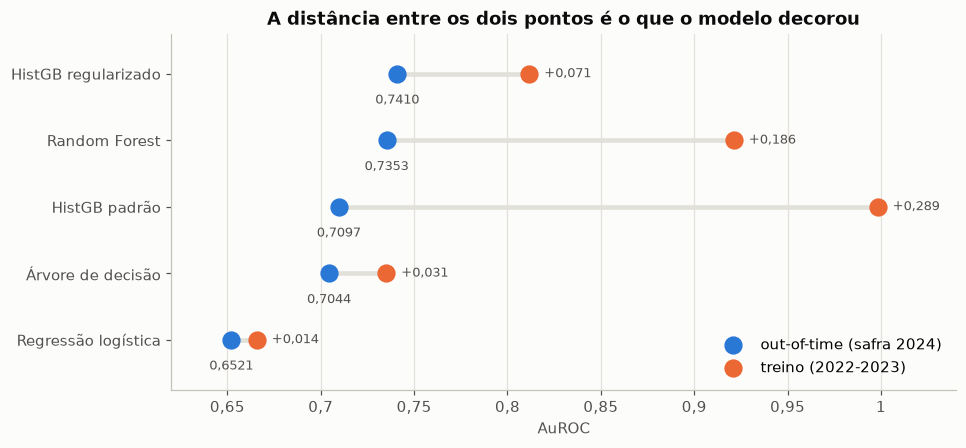

In [3]:
d = tab.sort_values("AUC OOT").reset_index(drop=True)
y = np.arange(len(d))

fig, ax = plt.subplots(figsize=(9.2, 4.2))
for yi, linha in d.iterrows():
    ax.plot([linha["AUC OOT"], linha["AUC treino"]], [yi, yi],
            color=GRADE, lw=3, zorder=1, solid_capstyle="round")
    ax.text(linha["AUC treino"] + 0.008, yi, "+" + br(linha["queda"], 3),
            va="center", fontsize=8.5, color=SECUNDARIA)
ax.scatter(d["AUC OOT"], y, s=120, color=AZUL, zorder=3, label="out-of-time (safra 2024)")
ax.scatter(d["AUC treino"], y, s=120, color=LARANJA, zorder=3, label="treino (2022-2023)")
# Rótulo do AuROC abaixo do ponto, não ao lado: à esquerda ele colide com o nome
# do modelo no eixo y, que é o erro que a primeira versão desta figura cometeu.
for yi, v in zip(y, d["AUC OOT"]):
    ax.text(v, yi - 0.30, br(v, 4), va="top", ha="center", fontsize=8.5, color=SECUNDARIA)

ax.set_yticks(y)
ax.set_yticklabels(d["modelo"])
ax.set_ylim(-0.75, len(d) - 0.4)
ax.set_xlim(0.62, 1.04)
ax.set_xlabel("AuROC")
ax.xaxis.set_major_formatter(VIRGULA)
ax.set_title("A distância entre os dois pontos é o que o modelo decorou")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
plt.show()

## 2. As curvas quase se sobrepõem

A margem do vencedor sobre a Random Forest ajustada é de **0,0057** de AuROC, contra um desvio de
validação de cerca de 0,02. Ou seja: a escolha **não é estatisticamente decisiva**, e a figura
abaixo existe para não deixar ninguém fingir que é.

O desempate está declarado no capítulo 04 e não vem do AuROC: vem da queda treino→teste (0,071
contra 0,186), do Brier e do KS.

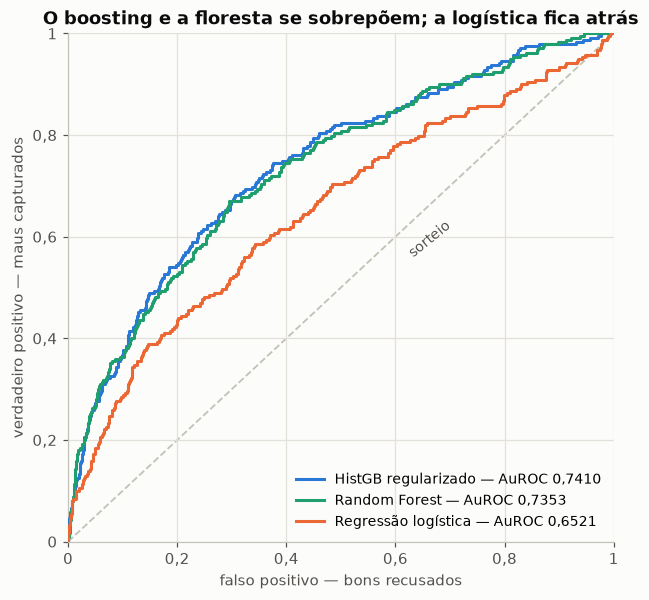

In [4]:
escolhidos = ["HistGB regularizado", "Random Forest", "Regressão logística"]
cores = {"HistGB regularizado": AZUL, "Random Forest": VERDE, "Regressão logística": LARANJA}

fig, ax = plt.subplots(figsize=(6.4, 6.0))
ax.plot([0, 1], [0, 1], color=EIXO, lw=1.2, ls="--", zorder=1)
ax.text(0.62, 0.56, "sorteio", fontsize=9, color=SECUNDARIA, rotation=39)

for nome in escolhidos:
    estimador, linear = candidatos()[nome]
    pipe = montar_pipeline(estimador, linear=linear).fit(matriz(treino), treino[ALVO])
    p = pipe.predict_proba(matriz(oot))[:, 1]
    fpr, tpr, _ = roc_curve(oot[ALVO], p)
    ax.plot(fpr, tpr, color=cores[nome], lw=2, zorder=3,
            label=f"{nome} — AuROC {br(roc_auc_score(oot[ALVO], p), 4)}")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(VIRGULA)
ax.yaxis.set_major_formatter(VIRGULA)
ax.set_xlabel("falso positivo — bons recusados")
ax.set_ylabel("verdadeiro positivo — maus capturados")
ax.set_title("O boosting e a floresta se sobrepõem; a logística fica atrás")
ax.legend(frameon=False, loc="lower right", fontsize=9)
plt.show()

## 3. Calibração: o que o AuROC não vê

O AuROC é invariante a qualquer transformação monótona da PD. Um modelo que prevê 3% onde a
realidade é 8% pode ter AuROC idêntico ao de um modelo correto — e arruinaria a precificação sem
que a métrica acusasse nada.

O teste é direto: separar a safra de 2024 em dez decis de risco, e comparar a PD média prevista com
a inadimplência que de fato aconteceu em cada decil. Ponto sobre a diagonal significa previsão no
nível certo.

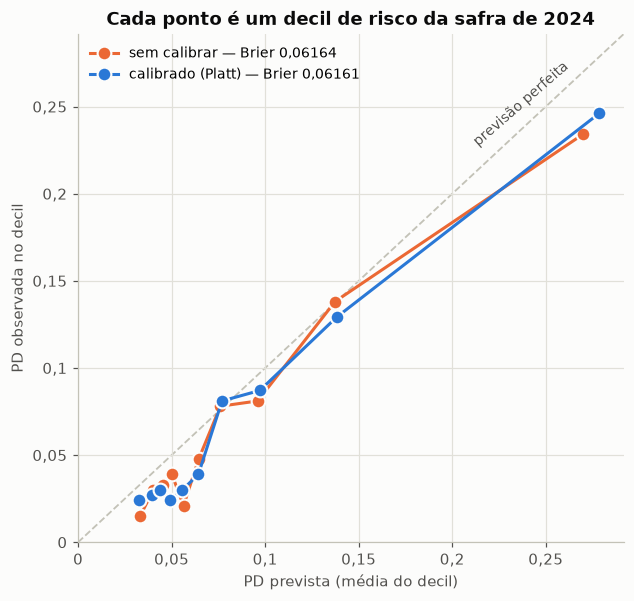

In [5]:
from sklearn.calibration import CalibratedClassifierCV

estimador, linear = candidatos()["HistGB regularizado"]
cru = montar_pipeline(estimador, linear=linear).fit(matriz(treino), treino[ALVO])
cal = CalibratedClassifierCV(montar_pipeline(estimador, linear=linear),
                             method="sigmoid", cv=5).fit(matriz(treino), treino[ALVO])

p_cru = cru.predict_proba(matriz(oot))[:, 1]
p_cal = cal.predict_proba(matriz(oot))[:, 1]
t_cru = tabela_calibracao(oot[ALVO], p_cru)
t_cal = tabela_calibracao(oot[ALVO], p_cal)

fig, ax = plt.subplots(figsize=(6.4, 6.0))
limite = max(t_cru["prevista"].max(), t_cru["observada"].max()) * 1.08
ax.plot([0, limite], [0, limite], color=EIXO, lw=1.2, ls="--", zorder=1)
ax.text(limite * 0.72, limite * 0.78, "previsão perfeita", fontsize=9,
        color=SECUNDARIA, rotation=41)
ax.plot(t_cru["prevista"], t_cru["observada"], "o-", color=LARANJA, lw=2, ms=9, zorder=3,
        markeredgecolor="#fcfcfb", markeredgewidth=1.4,
        label=f'sem calibrar — Brier {br(brier_score_loss(oot[ALVO], p_cru), 5)}')
ax.plot(t_cal["prevista"], t_cal["observada"], "o-", color=AZUL, lw=2, ms=9, zorder=4,
        markeredgecolor="#fcfcfb", markeredgewidth=1.4,
        label=f'calibrado (Platt) — Brier {br(brier_score_loss(oot[ALVO], p_cal), 5)}')

ax.set_xlim(0, limite)
ax.set_ylim(0, limite)
ax.xaxis.set_major_formatter(VIRGULA)
ax.yaxis.set_major_formatter(VIRGULA)
ax.set_xlabel("PD prevista (média do decil)")
ax.set_ylabel("PD observada no decil")
ax.set_title("Cada ponto é um decil de risco da safra de 2024")
ax.legend(frameon=False, loc="upper left", fontsize=9)
plt.show()

A calibração usa o método **sigmoide (Platt)**, não o isotônico. Os dois empatam em discriminação,
mas o isotônico é uma escada e devolve `PD = 1,0000` para dois contratos da Base A. PD de
exatamente 1 é indefensável como estimativa e envenena a perda esperada e o preço.

## 4. Da PD contínua para dez faixas

A política decide sobre faixas, não sobre a PD contínua. Agrupar custa **0,0029 de AuROC** — barato
pelo que se ganha em comunicabilidade.

As faixas são **desiguais de propósito**: largas no risco baixo, estreitas no alto. Separar 42% de
25% de PD cabe em 300 contratos; separar 3,3% de 3,4% não cabe em 2.000. Massa vai para o lado bom,
granularidade para o lado ruim.

A figura abaixo é a mais importante do projeto até aqui, e a barra de erro é o motivo.

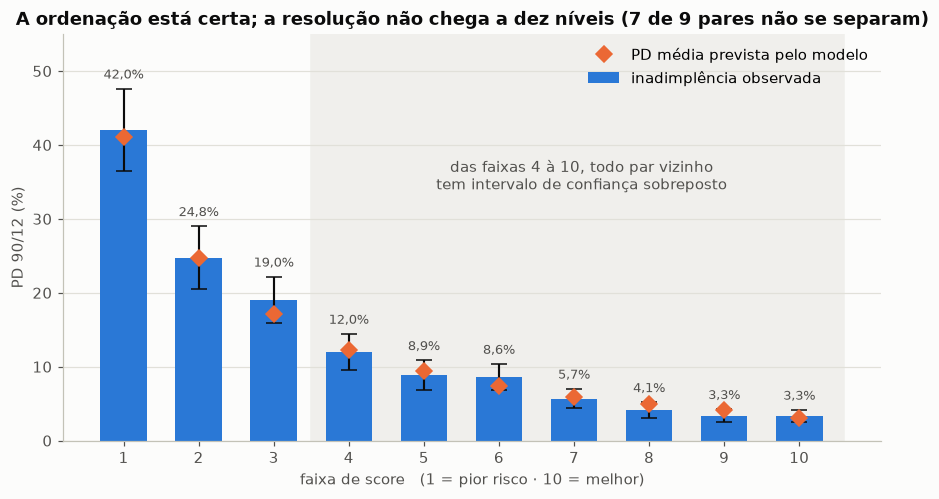

In [6]:
p_oof = pd_base_a()["pd_oof"].to_numpy()
t = tabela_faixas(p_oof, a[ALVO].to_numpy())
indistintos = pares_indistinguiveis(t)
x = np.arange(1, 11)

fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.axvspan(3.5, 10.6, color=NEUTRO, zorder=0)
ax.bar(x, t["pd_observada"] * 100, color=RAMPA_AZUL[4], width=0.62, zorder=2,
       label="inadimplência observada")
ax.errorbar(x, t["pd_observada"] * 100,
            yerr=[(t["pd_observada"] - t["ic_lo"]) * 100, (t["ic_hi"] - t["pd_observada"]) * 100],
            fmt="none", ecolor=TINTA, elinewidth=1.4, capsize=5, zorder=4)
ax.plot(x, t["pd_prevista"] * 100, "D", color=LARANJA, ms=7, zorder=5,
        label="PD média prevista pelo modelo")

# Rótulo acima do topo do intervalo de confiança, não acima da barra: nas três
# primeiras faixas a barra de erro é alta e a primeira versão sobrepôs os dois.
for xi, v, teto in zip(x, t["pd_observada"], t["ic_hi"]):
    ax.text(xi, teto * 100 + 1.4, br(v * 100, 1, "%"), ha="center", fontsize=8.5,
            color=SECUNDARIA)
ax.text(7.1, 34, "das faixas 4 à 10, todo par vizinho\ntem intervalo de confiança sobreposto",
        ha="center", fontsize=9.5, color=SECUNDARIA)

ax.set_xticks(x)
ax.set_xlabel("faixa de score   (1 = pior risco · 10 = melhor)")
ax.set_ylabel("PD 90/12 (%)")
ax.set_ylim(0, 55)
ax.set_title(f"A ordenação está certa; a resolução não chega a dez níveis "
             f"({len(indistintos)} de 9 pares não se separam)", fontsize=11.5)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
plt.show()

A leitura honesta: a **ordenação** está correta de ponta a ponta — a faixa 1 quebra 12,6 vezes mais
que a faixa 10, o rho de Spearman é −0,988 e não há nenhuma inversão fora do intervalo de
confiança. O que não existe é **resolução para dez níveis**. Com 10.000 contratos e PD média de
8,26%, a Base A sustenta quatro ou cinco degraus distinguíveis.

A consequência prática, que o capítulo 07 herda: a política diferencia **grupos de faixas**. A
submissão reporta as dez porque o campo `score_1a10` exige.

## 5. A régua é estável — até encontrar a Base C

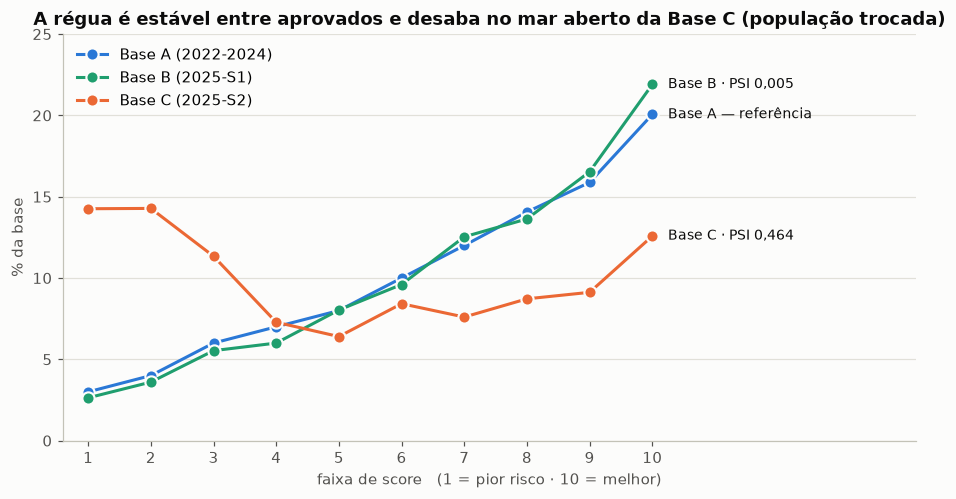

In [7]:
final = treinar_final(a)
f_a = faixa(p_oof)
f_b = faixa(prever(final, b))
f_c = faixa(prever(final, preparar_aplicacao(c)))

psi_b, psi_c = estabilidade(f_a, f_b), estabilidade(f_a, f_c)

# O PSI viaja no rótulo direto de cada linha, em vez de num bloco de texto solto:
# menos tinta, e o número fica ao lado da série que ele descreve.
perfis = {
    "Base A (2022-2024)": (f_a, AZUL, "Base A — referência"),
    "Base B (2025-S1)": (f_b, VERDE, f"Base B · PSI {br(psi_b, 3)}"),
    "Base C (2025-S2)": (f_c, LARANJA, f"Base C · PSI {br(psi_c, 3)}"),
}
x = np.arange(1, 11)

fig, ax = plt.subplots(figsize=(10.0, 4.8))
for rotulo, (f, cor, direto) in perfis.items():
    pct = pd.Series(f).value_counts(normalize=True).reindex(x).fillna(0) * 100
    ax.plot(x, pct, "-o", color=cor, lw=2, ms=8, zorder=3, label=rotulo,
            markeredgecolor="#fcfcfb", markeredgewidth=1.4)
    ax.text(10.25, pct.iloc[-1], direto, va="center", fontsize=9, color=TINTA)

ax.set_xticks(x)
ax.set_xlim(0.6, 14.2)
ax.set_ylim(0, 25)
ax.yaxis.set_major_formatter(VIRGULA)
ax.set_xlabel("faixa de score   (1 = pior risco · 10 = melhor)")
ax.set_ylabel("% da base")
ax.set_title(f"A régua é estável entre aprovados e desaba no mar aberto da Base C "
             f"({classificar_psi(psi_c).lower()})", fontsize=11.5)
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="x", visible=False)
plt.show()

Dentro do universo de contratos aprovados a régua praticamente não se move: PSI de 0,006 na Base B,
que é meio ano posterior a tudo que o modelo viu. A Base C dá **0,473** — o que a régua de mercado
chama de população trocada.

Isso não é deterioração do modelo. É o **viés de aprovados** medido num número só: as bases A e B
contêm apenas quem a política antiga aprovou; a Base C é mar aberto e inclui perfis que a AutoCred
recusava. É o principal risco técnico do desafio.

E impõe o limite de honestidade da defesa: a tabela de faixas foi validada em aprovados. A faixa 1
da Base C tem 713 propostas com PD prevista média de 43,1%, e boa parte desse perfil nunca recebeu
crédito nesta casa. Para elas o número é **extrapolação, não medição** — e árvore não extrapola,
repete a folha mais próxima.

## 6. O que a política vai encontrar

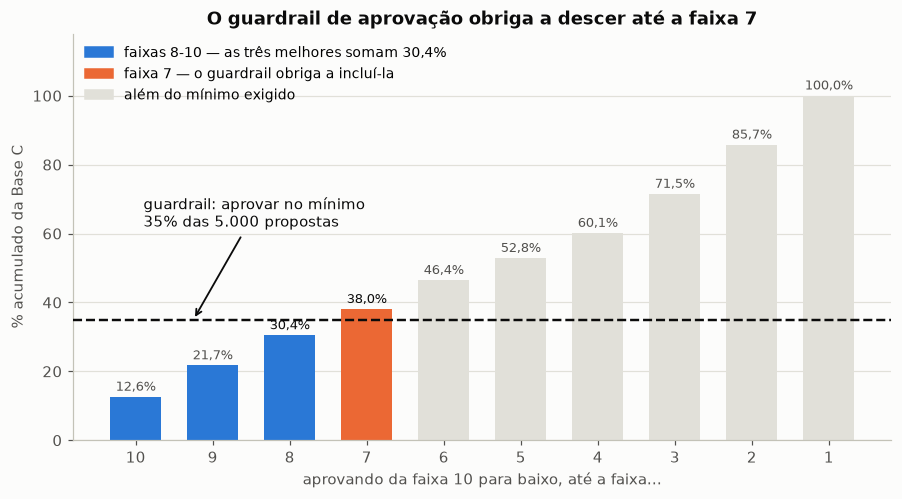

In [8]:
tc = tabela_faixas(prever(final, preparar_aplicacao(c)))
acum = tc.sort_index(ascending=False)["pct"].cumsum() * 100
ordem = list(range(10, 0, -1))
x = np.arange(len(ordem))
cores = [AZUL if f >= 8 else (LARANJA if f == 7 else GRADE) for f in ordem]

fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.bar(x, acum.reindex(ordem), color=cores, width=0.66, zorder=2)
ax.axhline(35, color=TINTA, lw=1.6, ls="--", zorder=3)
for xi, f in zip(x, ordem):
    v = acum.loc[f]
    ax.text(xi, v + 1.8, br(v, 1, "%"), ha="center", fontsize=8.5,
            color=TINTA if f in (7, 8) else SECUNDARIA)

# A anotação vai para o canto superior esquerdo — a única região da figura que as
# barras não ocupam, já que o acumulado cresce da esquerda para a direita.
ax.annotate("guardrail: aprovar no mínimo\n35% das 5.000 propostas",
            xy=(0.75, 35), xytext=(0.1, 62), fontsize=9.5, color=TINTA,
            arrowprops=dict(arrowstyle="->", color=TINTA, lw=1.2))

legenda = [
    Patch(color=AZUL, label="faixas 8-10 — as três melhores somam 30,4%"),
    Patch(color=LARANJA, label="faixa 7 — o guardrail obriga a incluí-la"),
    Patch(color=GRADE, label="além do mínimo exigido"),
]
ax.legend(handles=legenda, frameon=False, loc="upper left", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([str(f) for f in ordem])
ax.set_xlabel("aprovando da faixa 10 para baixo, até a faixa...")
ax.set_ylabel("% acumulado da Base C")
ax.set_ylim(0, 118)
ax.set_title("O guardrail de aprovação obriga a descer até a faixa 7")
ax.grid(axis="x", visible=False)
plt.show()

Esta figura restringe a política antes de ela ser escrita. O guardrail exige aprovar **no mínimo
35%** das 5.000 propostas, e as faixas 8, 9 e 10 somam apenas **30,4%**. Aprovar só as três
melhores faixas **reprova no guardrail** — é obrigatório descer até a faixa 7 (38,0% acumulado) ou
aprovar parte da faixa 6 sob condições mais duras.

Os outros três guardrails — CET de 3,5% a.m., inadimplência de 8% e volume de R$ 40 milhões — ainda
não foram testados contra essa escolha. É o trabalho dos capítulos 06 e 07.

---

*Gerado por `notebooks/gerar_notebook_modelagem.py`, que consome `src/modelo.py` e `src/score.py` —
as mesmas funções do pipeline, para que notebook e entregável não possam divergir. Os números
saem das funções; nenhum é digitado.*